In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Social Media Engagement Dataset.csv")

# Show basic info

In [3]:
print("Dataset Preview:")
print(df.head())

print("\nDataset Info:")
print(df.info())

Dataset Preview:
        post_id         timestamp day_of_week   platform        user_id  \
0  kcqbs6hxybia  09-12-2024 11:26      Monday  Instagram  user_52nwb0a6   
1  vkmervg4ioos  28-07-2024 19:59      Sunday    Twitter  user_ucryct98   
2  memhx4o1x6yu  23-11-2024 14:00    Saturday     Reddit  user_7rrev126   
3  bhyo6piijqt9  16-09-2024 04:35      Monday    YouTube  user_4mxuq0ax   
4  c9dkiomowakt  05-09-2024 21:03    Thursday    Twitter  user_l1vpox2k   

               location language  \
0  Melbourne, Australia       pt   
1          Tokyo, Japan       ru   
2        Beijing, China       ru   
3        Lagos, Nigeria       en   
4       Berlin, Germany       hi   

                                        text_content  \
0  Just tried the Chromebook from Google. Best pu...   
1  Just saw an ad for Microsoft Surface Laptop du...   
2  What's your opinion about Nike's Epic React?  ...   
3  Bummed out with my new Diet Pepsi from Pepsi! ...   
4  Just tried the Corolla from Toyo

In [4]:
print(df.columns)


Index(['post_id', 'timestamp', 'day_of_week', 'platform', 'user_id',
       'location', 'language', 'text_content', 'hashtags', 'mentions',
       'keywords', 'topic_category', 'sentiment_score', 'sentiment_label',
       'emotion_type', 'toxicity_score', 'likes_count', 'shares_count',
       'comments_count', 'impressions', 'engagement_rate', 'brand_name',
       'product_name', 'campaign_name', 'campaign_phase',
       'user_past_sentiment_avg', 'user_engagement_growth',
       'buzz_change_rate'],
      dtype='object')



# 2. Analyze likes, shares, comments


In [5]:
print("\nBasic Statistics:")
print(df[['likes_count', 'shares_count', 'comments_count']].describe())




Basic Statistics:
       likes_count  shares_count  comments_count
count  12000.00000  12000.000000     12000.00000
mean    2490.72025   1007.167167       504.34575
std     1441.53253    575.072282       288.68416
min        0.00000      0.000000         0.00000
25%     1236.00000    510.000000       253.00000
50%     2496.00000   1018.000000       503.00000
75%     3723.25000   1501.000000       755.00000
max     5000.00000   2000.000000      1000.00000


# 3. Identify most engaging posts

In [6]:

 df['Total_Engagement'] = df['likes_count'] + df['shares_count'] + df['comments_count']
top_posts = df.sort_values(by='Total_Engagement', ascending=False).head(10)

print("\nTop 10 Most Engaging Posts:")
print(top_posts)


Top 10 Most Engaging Posts:
            post_id         timestamp day_of_week   platform        user_id  \
459    7v5a8zyj4gw5  23-06-2024 09:31      Sunday    YouTube  user_qbclaspk   
11947  ycjj5zzt7mvx  19-02-2025 05:57   Wednesday  Instagram  user_3w27ggio   
8925   3dh1ecglz4bd  04-06-2024 16:23     Tuesday     Reddit  user_np966onv   
3075   wo7py9aljg3t  28-04-2025 20:25      Monday     Reddit  user_50qjuqdj   
1770   gmoeib832zbs  24-01-2025 10:39      Friday   Facebook  user_kk1decwg   
6899   5kvuyvf38nqx  09-06-2024 14:59      Sunday    YouTube  user_n6p8x5xw   
11154  pvfl3d8hj7jd  15-05-2024 14:02   Wednesday  Instagram  user_jwq9kwt4   
4093   tdgjjylpua20  02-06-2024 14:39      Sunday    YouTube  user_j2o4po42   
3881   tne7s3o4l4wd  30-10-2024 11:45   Wednesday  Instagram  user_ix1d6h8j   
6398   kwt9yuwjsw74  28-12-2024 17:25    Saturday    Twitter  user_oa2wz7nx   

                 location language  \
459    Seoul, South Korea       ru   
11947          London, UK

# 4. Visualization

### i. Likes, Shares, Comments Distribution

<Figure size 640x480 with 0 Axes>

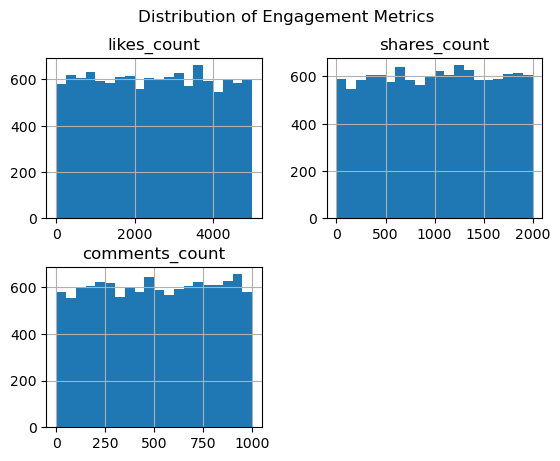

In [7]:
plt.figure()
df[['likes_count', 'shares_count', 'comments_count']].hist(bins=20)
plt.suptitle("Distribution of Engagement Metrics")
plt.show()

### ii. Engagement Comparison (Bar Chart)

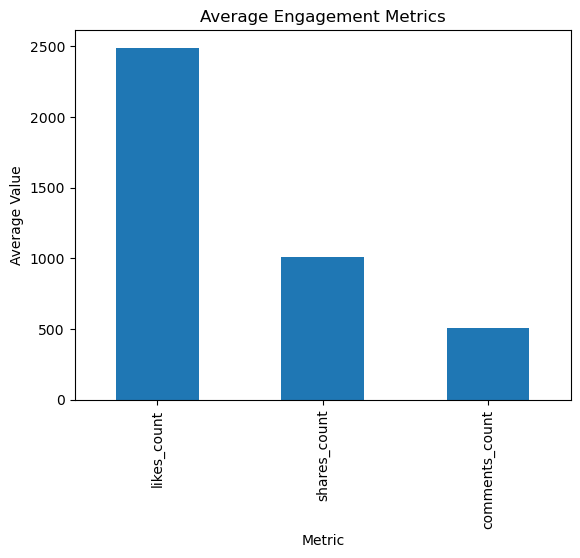

In [8]:
plt.figure()
avg_values = df[['likes_count', 'shares_count', 'comments_count']].mean()
avg_values.plot(kind='bar')
plt.title("Average Engagement Metrics")
plt.xlabel("Metric")
plt.ylabel("Average Value")
plt.show()

### iii. Top Posts Visualization

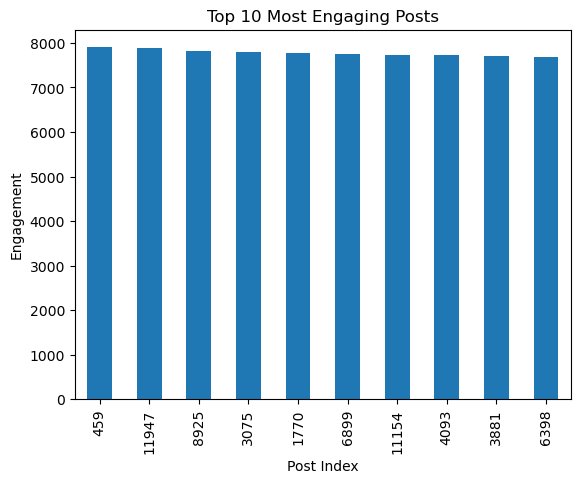

In [9]:
plt.figure()
top_posts['Total_Engagement'].plot(kind='bar')
plt.title("Top 10 Most Engaging Posts")
plt.xlabel("Post Index")
plt.ylabel("Engagement")
plt.show()


### iv. Correlation Heatmap

In [10]:
plt.figure()
corr = df[['likes_count', 'shares_count', 'comments_count']].corr()
print("\nCorrelation Matrix:\n", corr)



Correlation Matrix:
                 likes_count  shares_count  comments_count
likes_count        1.000000      0.002741        0.007044
shares_count       0.002741      1.000000        0.024406
comments_count     0.007044      0.024406        1.000000


<Figure size 640x480 with 0 Axes>

# 5. Insights

In [11]:
print("\nINSIGHTS:")

print(f"- Average Likes: {df['likes_count'].mean():.2f}")
print(f"- Average Shares: {df['shares_count'].mean():.2f}")
print(f"- Average Comments: {df['comments_count'].mean():.2f}")

most_liked = df.loc[df['likes_count'].idxmax()]
print("\nMost Liked Post:")
print(most_liked)

most_shared = df.loc[df['shares_count'].idxmax()]
print("\nMost Shared Post:")
print(most_shared)

most_commented = df.loc[df['comments_count'].idxmax()]
print("\nMost Commented Post:")
print(most_commented)


INSIGHTS:
- Average Likes: 2490.72
- Average Shares: 1007.17
- Average Comments: 504.35

Most Liked Post:
post_id                                                         87gq6xrd3ykv
timestamp                                                   13-01-2025 22:40
day_of_week                                                           Monday
platform                                                              Reddit
user_id                                                        user_sq4ch5k2
location                                                        Chicago, USA
language                                                                  en
text_content               My one year review of Adidas Samba: Worth ever...
hashtags                                                            #Quality
mentions                                                        @ProductTeam
keywords                             luxury, premium, amazing, disappointing
topic_category                                

In [12]:
print(df.columns)


Index(['post_id', 'timestamp', 'day_of_week', 'platform', 'user_id',
       'location', 'language', 'text_content', 'hashtags', 'mentions',
       'keywords', 'topic_category', 'sentiment_score', 'sentiment_label',
       'emotion_type', 'toxicity_score', 'likes_count', 'shares_count',
       'comments_count', 'impressions', 'engagement_rate', 'brand_name',
       'product_name', 'campaign_name', 'campaign_phase',
       'user_past_sentiment_avg', 'user_engagement_growth', 'buzz_change_rate',
       'Total_Engagement'],
      dtype='object')


In [13]:

print("\nTop Posts by Engagement Rate:")
print(df.sort_values(by='engagement_rate', ascending=False).head(5))


Top Posts by Engagement Rate:
            post_id         timestamp day_of_week   platform        user_id  \
2880   67d6fsv09zzv  21-08-2024 00:02   Wednesday     Reddit  user_odj3nlo2   
11926  h03dprdsxb4t  05-11-2024 00:10     Tuesday  Instagram  user_3us7ozg2   
719    u50pnlesq1y8  30-12-2024 21:31      Monday     Reddit  user_1r1zn4lc   
10917  h4btj68pyn9j  28-09-2024 14:22    Saturday    YouTube  user_grb4vql7   
7967   k508grdqqbne  07-02-2025 18:46      Friday    YouTube  user_k9fjjzk5   

              location language  \
2880     Paris, France       hi   
11926  Shanghai, China       es   
719         London, UK       en   
10917    Paris, France       zh   
7967       Rome, Italy       pt   

                                            text_content  \
2880   Just unboxed my new Galaxy S25 from Samsung. M...   
11926  Just tried the Zoom Pegasus from Nike. Wouldn'...   
719    What's your opinion about Microsoft's Xbox Eli...   
10917  Should I upgrade about Microsoft's S